In [1]:
import os
import pandas as pd
import numpy as np
import random
import warnings
warnings.filterwarnings(action = "ignore")
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import copy
import ab_sim as sim_mod

In [2]:
with open("initial_inputs_all.pkl", "rb") as input1:
    initial_inputs = pickle.load(input1)

initial_inputs

{'burn_in_days': 3650,
 'T_low': 0.01,
 'T_high': 0.15,
 'R_low': 0.04,
 'R_high': 0.08,
 'I_low': 1,
 'I_high': 6,
 'IC_low': 1,
 'IC_high': 10,
 'n_sims': 1000,
 'n_calls_gp': 1000,
 'n_random_starts': 500}

In [3]:
with open("case_inputs_all.pkl", "rb") as input2:
    farm = pickle.load(input2)
farm1 = farm['Farm1']
farm2 = farm['Farm2']
farm3 = farm['Farm3']
farm4 = farm['Farm4']

farm1.keys()

dict_keys(['internal_name', 'num_cows_to_add_burn_in', 'initial_infected', 'T', 'R', 'Incubation', 'target_curve', 'ndays_target', 'burn_in_days', 'no_calves', 'burn_in_farm'])

In [5]:
print(farm1['internal_name'],farm2['internal_name'],farm3['internal_name'],farm4['internal_name']) 

w t d va


# Farm 1

In [4]:
sim_list = sim_mod.run_main_simulation(burn_in_farm_state = farm1['burn_in_farm'], 
                                      merge_dwell_df = sim_mod.merge_dwell, 
                                      ndays = 365, 
                                      burn_in_days = 3650, 
                                      initial_infected = farm1['initial_infected'], 
                                      transmission_rate = farm1['T'], 
                                      recovery_rate = farm1['R'], 
                                      incubation_period = farm1['Incubation'], 
                                      pens_to_mask=['Pen1', 'Pen2', 'Pen3', 'Pen4'],
                                      num_simulations=100)

In [64]:
summary_list = []
for df in sim_list['seir_history']:
    alive_counts = (
        df[df['alive']]
        .groupby(['day', 'pen'])
        .size()
        .reset_index(name='count')
    )
    summary_list.append(alive_counts)

# Concatenate and make a multi-indexed DataFrame
all_runs = pd.concat(summary_list, keys=range(len(summary_list)), names=['sim', 'idx'])

# Pivot to have sims as columns (for aggregation)
all_runs_pivot = all_runs.pivot_table(index=['day', 'pen'], columns='sim', values='count').fillna(0)

day_pen = all_runs[['day', 'pen']].drop_duplicates()

# For each combination, get the counts across all sims
results = []
for _, row in day_pen.iterrows():
    day = row['day']
    pen = row['pen']
    # print(f"Pen: {pen}, Day: {day}, Counts: {vals}")
    # All runs for this day/pen
    vals = all_runs[(all_runs['day'] == day) & (all_runs['pen'] == pen)]['count'].values
    median = np.median(vals)
    q1 = np.percentile(vals, 25)
    q3 = np.percentile(vals, 75)
    iqr = q3 - q1
    results.append({'pen': pen, 'day': day, 'median': median, 'iqr': iqr})

summary_df = pd.DataFrame(results)

summary_df

,pen,day,median,iqr
0,Pen1,1,57.0,0.0
1,Pen10,1,93.0,0.0
2,Pen11,1,101.0,0.0
3,Pen12,1,25.0,0.0
4,Pen13,1,5.0,0.0
...,...,...,...,...
5468,Pen13,53,1.0,0.0
5469,Pen13,96,1.0,0.0
5470,Pen13,150,1.0,0.5
5471,Pen13,127,1.0,0.0


In [65]:
pen_labels = pd.DataFrame({'pen': [f'Pen{i}' for i in range(1, 16)],
                        'label' : ["Prewean",
                                  "Postwean",
                                  "Breeding",
                                  "Pregnant",
                                  "Springer",
                                  "Fresh_p",
                                  "Fresh_m",
                                  "High_milk_p",
                                  "Low_milk_p",
                                  "High_milk_m",
                                  "Low_milk_m",
                                  "Dry_cow",
                                  "Close_up",
                                  "Calving",
                                  "Hospital"]})
pen_labels

,pen,label
0,Pen1,Prewean
1,Pen2,Postwean
2,Pen3,Breeding
3,Pen4,Pregnant
4,Pen5,Springer
5,Pen6,Fresh_p
6,Pen7,Fresh_m
7,Pen8,High_milk_p
8,Pen9,Low_milk_p
9,Pen10,High_milk_m


In [66]:
summary_df['pen'] = summary_df['pen'].astype(str)
ordered_pens = [f'Pen{i}' for i in range(1, 15+1)]

# Get label mapping from pen_labels (assumes 'pen'/'label' in pen_labels)
pen_to_label = dict(zip(pen_labels['pen'], pen_labels['label']))
ordered_labels = [pen_to_label[pen] for pen in ordered_pens]


In [69]:
summary_df.to_csv("farm1_pen_counts.csv", index=False)

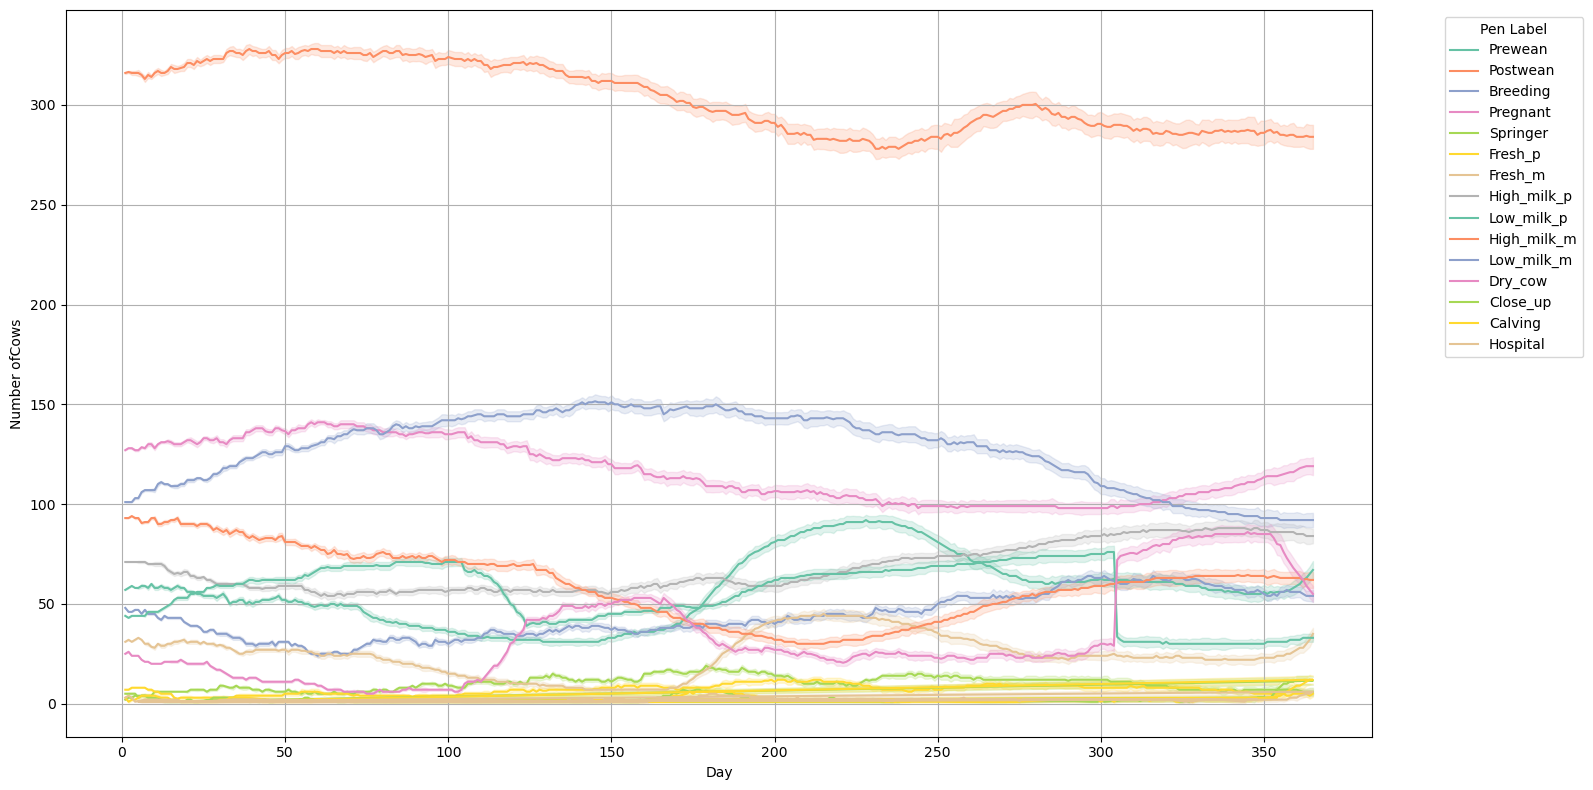

In [8]:
palette = sns.color_palette('Set2', n_colors=15) 
color_dict = {label: palette[i % len(palette)] for i, label in enumerate(ordered_labels)}

plt.figure(figsize=(16, 8))
for pen, label in zip(ordered_pens, ordered_labels):
    group = summary_df[summary_df['pen'] == pen]
    if not group.empty:
        color = color_dict.get(label, 'gray')
        plt.plot(group['day'], group['median'], label=label, color=color)
        plt.fill_between(group['day'],
                         group['median'] - group['iqr'] / 2,
                         group['median'] + group['iqr'] / 2,
                         color=color, alpha=0.2)

plt.xlabel('Day')
plt.ylabel('Number ofCows')
# Legend: Only show labels in pen order
handles, legend_labels = plt.gca().get_legend_handles_labels()
# Reorder legend according to ordered_labels
legend_order = [ordered_labels.index(lbl) for lbl in legend_labels if lbl in ordered_labels]
handles = [handles[i] for i in np.argsort(legend_order)]
labels = [legend_labels[i] for i in np.argsort(legend_order)]
plt.legend(handles, labels, title='Pen Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()  
plt.tight_layout()
plt.savefig("pen_counts.tiff", dpi = 300)
plt.show()

In [70]:
seir_summary_list = []
for df in sim_list['seir_history']:
    # Only include alive cows
    df_alive = df[df['alive']]
    # Count per state per day
    counts = df_alive.groupby(['day', 'state']).size().reset_index(name='count')
    seir_summary_list.append(counts)

seir_summary_list[1]

,day,state,count
0,1,Exposed,7
1,1,Infectious,10
2,1,Susceptible,916
3,2,Exposed,12
4,2,Infectious,10
...,...,...,...
1416,364,Susceptible,719
1417,365,Exposed,1
1418,365,Infectious,10
1419,365,Recovered,194


In [71]:
all_counts = pd.concat(seir_summary_list, keys=range(len(seir_summary_list)), names=['sim', 'idx'])
# For easier aggregation:
pivoted = all_counts.pivot_table(index=['day', 'state'], columns='sim', values='count', fill_value=0)

# Compute stats for each state and day
results = []
for (day, state), vals in pivoted.iterrows():
    med = np.median(vals)
    q1 = np.percentile(vals, 25)
    q3 = np.percentile(vals, 75)
    iqr = q3 - q1
    results.append({'day': day, 'state': state, 'median': med, 'iqr': iqr})
states_summary = pd.DataFrame(results)
states_summary.head()

,day,state,median,iqr
0,1,Exposed,6.0,2.50
1,1,Infectious,10.0,0.00
2,1,Susceptible,916.0,4.00
3,2,Exposed,11.0,4.25
4,2,Infectious,10.0,1.00


In [73]:
states_summary.to_csv("farm1_seir.csv", index = False)

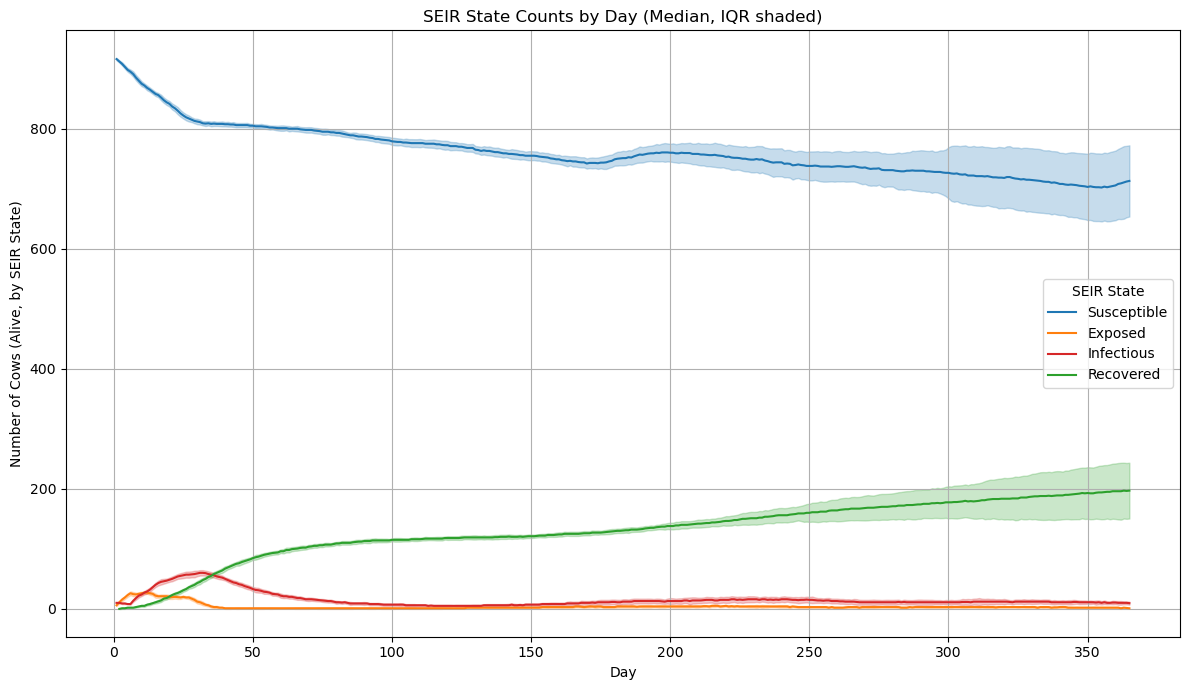

In [11]:
state_palette = {'Susceptible': '#1f77b4', 'Exposed': '#ff7f0e', 'Infectious': '#d62728', 'Recovered': '#2ca02c'}

plt.figure(figsize=(12, 7))
for state in ['Susceptible', 
              'Exposed',
              'Infectious',
              'Recovered']:
    g = states_summary[states_summary['state'] == state]
    g = g.sort_values('day')
    plt.plot(g['day'], g['median'], label=state, color=state_palette.get(state))
    plt.fill_between(g['day'],
                     g['median'] - g['iqr'] / 2,
                     g['median'] + g['iqr'] / 2,
                     color=state_palette.get(state, 'gray'),
                     alpha=0.25)

plt.xlabel('Day')
plt.ylabel('Number of Cows (Alive, by SEIR State)')
plt.title('SEIR State Counts by Day (Median, IQR shaded)')
plt.legend(title='SEIR State')
plt.grid()  
plt.tight_layout()
plt.show()

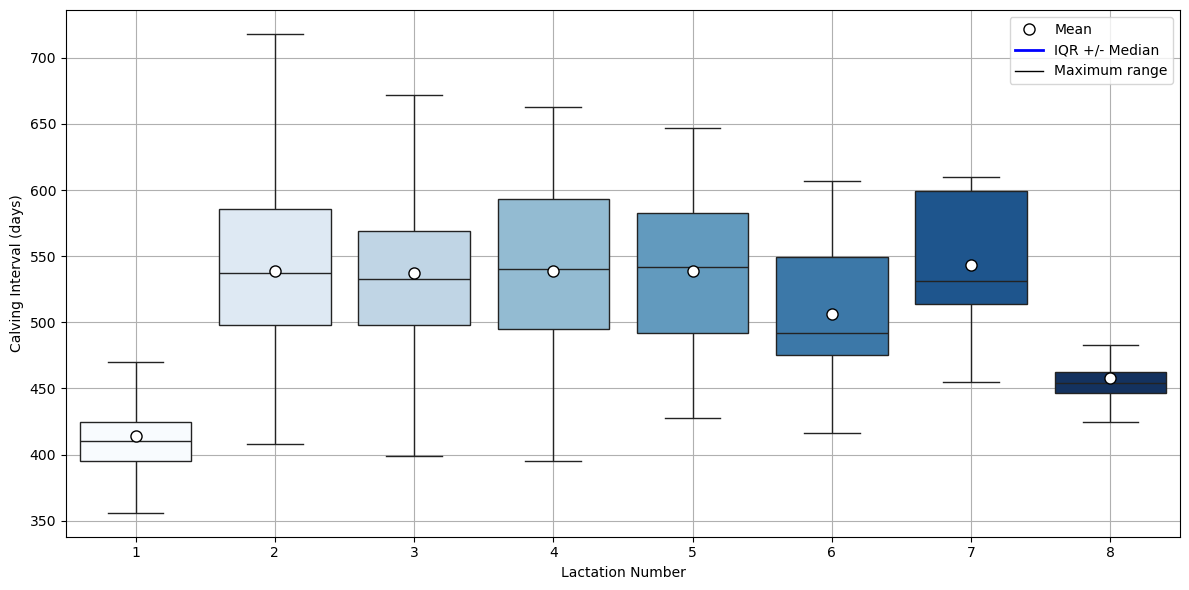

In [74]:
from matplotlib.lines import Line2D

# Concatenate calving intervals, as before
ci_lactation_list = []
for df in sim_list['calving_intervals']:
    valid = df[df['calv_interval'].notnull()]
    ci_lactation_list.append(valid[['lactation_number', 'calv_interval']])

all_ci = pd.concat(ci_lactation_list, ignore_index=True)

# Remove lactation_number == 0
all_ci = all_ci[all_ci['lactation_number'] != 0]

# Plot boxplots
plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    x='lactation_number',
    y='calv_interval',
    hue = 'lactation_number',
    palette = 'Blues',
    data=all_ci,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", 
               "markeredgecolor":"black", "markersize":8},
    showfliers=False
)

plt.xlabel('Lactation Number')
plt.ylabel('Calving Interval (days)')

# Custom legend handles:
mean_legend = Line2D([0], [0], marker='o', color='w',
                      markerfacecolor='white', markeredgecolor='black',
                      markersize=8, label='Mean')
box_legend = Line2D([0], [0], color='blue', lw=2, label='IQR +/- Median')
whisker_legend = Line2D([0], [0], color='black', lw=1, label='Maximum range')

# Show only custom symbols (means, box, whisker), because lactation numbers are x-tick labels
plt.legend(handles=[mean_legend, box_legend, whisker_legend], 
           loc='best')
plt.grid()  
plt.tight_layout()
plt.savefig("calving_intervals.tiff", dpi = 300)
plt.show()


In [76]:
all_ci.to_csv("farm1_ci.csv", index = False)

In [13]:
sim_list['days_in_milk'][0]

,cow_id,lactation_number,days_in_milk
0,137,6,369
1,199,6,368
2,244,8,425
3,275,6,418
4,292,8,367
...,...,...,...
879,4102,0,0
880,4103,0,0
881,4104,0,0
882,4105,0,0


In [14]:
sim_list['lactation_summary'][0]

,cow_id,max_lactation,days_in_milk_per_lactation
0,137,6,"{0: 0, 1: 314, 2: 470, 3: 397, 4: 509, 5: 428}"
1,199,6,"{0: 0, 1: 326, 2: 456, 3: 455, 4: 423, 5: 492}"
2,241,6,"{0: 0, 1: 307, 2: 320, 3: 357, 4: 418, 5: 448}"
3,244,8,"{0: 0, 1: 317, 2: 393, 3: 465, 4: 338, 5: 300,..."
4,275,6,"{0: 0, 1: 332, 2: 403, 3: 426, 4: 482, 5: 420}"
...,...,...,...
1219,4102,0,{}
1220,4103,0,{}
1221,4104,0,{}
1222,4105,0,{}


In [77]:
all_lact_summary = []
for df in sim_list['lactation_summary']:
    valid = df[df['max_lactation'] != 0]
    avg_lact = valid['max_lactation'].mean()
    std_lact = valid['max_lactation'].std()
    dim = []
    for dd in valid['days_in_milk_per_lactation']:
        for k, v in dd.items():
            # Exclude lactation 0 if present (usually dry-off)
            if k != 0:
                dim.append(v)
    if dim:
        median_dim = np.median(dim)
        q1_dim = np.percentile(dim, 25)
        q3_dim = np.percentile(dim, 75)
        iqr_dim = q3_dim - q1_dim
    else:
        median_dim, iqr_dim = np.nan, np.nan
    
    all_lact_summary.append({
        'average_lactation_number': avg_lact,
        'stddev_lactation_number': std_lact,
        'median_days_in_milk': median_dim,
        'iqr_days_in_milk': iqr_dim
    })

summary_lact = pd.DataFrame(all_lact_summary)
# print(summary_df.describe())
summary_lact

,average_lactation_number,stddev_lactation_number,median_days_in_milk,iqr_days_in_milk
0,2.368522,1.665974,363.0,97.00
1,2.375940,1.667690,367.0,97.00
2,2.359023,1.668602,364.0,97.00
3,2.415861,1.687614,366.0,97.00
4,2.400000,1.698237,363.5,97.25
...,...,...,...,...
95,2.383743,1.665776,367.0,98.00
96,2.399232,1.688741,365.0,97.00
97,2.412879,1.697186,364.5,96.75
98,2.379771,1.665891,364.0,96.00


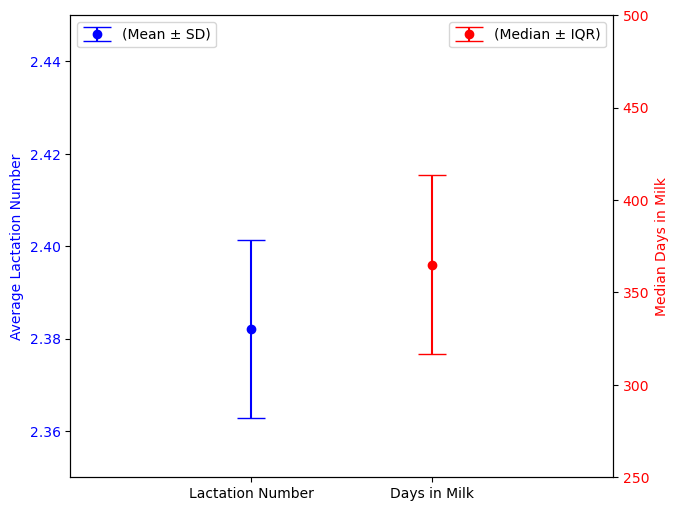

In [78]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(7, 6))

x1 = 0.4
x2 = 0.6

N = len(summary_lact)

# Lactation number
lat_mean = summary_lact['average_lactation_number'].mean()
lat_sem = summary_lact['average_lactation_number'].std()
lat_ci95 = 1 * lat_sem
lat_max = max(lat_mean + lat_ci95, summary_lact['average_lactation_number'].max())
ax1.errorbar(
    x=x1, y=lat_mean, yerr=lat_ci95,
    fmt='o', color='blue', capsize=10, label='(Mean ± SD)'
)
ax1.set_ylabel('Average Lactation Number', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Expand y-limits to 150%
ax1.set_ylim(2.35, 2.45)
# Days in milk
dim_median = summary_lact['median_days_in_milk'].median()
dim_iqr = summary_lact['iqr_days_in_milk'].median()
dim_max = max(dim_median + (dim_iqr / 2), summary_lact['median_days_in_milk'].max())
ax2 = ax1.twinx()
ax2.errorbar(
    x=x2, y=dim_median, yerr=dim_iqr/2,
    fmt='o', color='red', capsize=10, label='(Median ± IQR)'
)
ax2.set_ylabel('Median Days in Milk', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Expand y-limits to 150%
ax2.set_ylim(250, 500)

# Center x-ticks
ax1.set_xticks([x1, x2])
ax1.set_xticklabels(['Lactation Number', 'Days in Milk'])
ax1.set_xlim(0.2, 0.8)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# plt.tight_layout()
plt.savefig("dim_lact.tiff", dpi = 300)
plt.show()


In [81]:
summary_lact.to_csv("farm1_lact_sum.csv", index = False)

# Farm 2

In [19]:
sim_list2 = sim_mod.run_main_simulation(burn_in_farm_state = farm2['burn_in_farm'], 
                                      merge_dwell_df = sim_mod.merge_dwell, 
                                      ndays = 365, 
                                      burn_in_days = 3650, 
                                      initial_infected = farm2['initial_infected'], 
                                      transmission_rate = farm2['T'], 
                                      recovery_rate = farm2['R'], 
                                      incubation_period = farm2['Incubation'], 
                                      pens_to_mask=['Pen1', 'Pen2', 'Pen3', 'Pen4'],
                                      num_simulations=100)

In [82]:
summary_list2 = []
for df in sim_list2['seir_history']:
    alive_counts = (
        df[df['alive']]
        .groupby(['day', 'pen'])
        .size()
        .reset_index(name='count')
    )
    summary_list2.append(alive_counts)

# Concatenate and make a multi-indexed DataFrame
all_runs2 = pd.concat(summary_list2, keys=range(len(summary_list2)), names=['sim', 'idx'])

# Pivot to have sims as columns (for aggregation)
all_runs_pivot2 = all_runs2.pivot_table(index=['day', 'pen'], columns='sim', values='count').fillna(0)

day_pen2 = all_runs2[['day', 'pen']].drop_duplicates()

# For each combination, get the counts across all sims
results2 = []
for _, row in day_pen2.iterrows():
    day = row['day']
    pen = row['pen']
    # print(f"Pen: {pen}, Day: {day}, Counts: {vals}")
    # All runs for this day/pen
    vals = all_runs2[(all_runs2['day'] == day) & (all_runs2['pen'] == pen)]['count'].values
    median = np.median(vals)
    q1 = np.percentile(vals, 25)
    q3 = np.percentile(vals, 75)
    iqr = q3 - q1
    results2.append({'pen': pen, 'day': day, 'median': median, 'iqr': iqr})

summary_df2 = pd.DataFrame(results2)

summary_df2

,pen,day,median,iqr
0,Pen1,1,36.0,0.0
1,Pen10,1,53.0,0.0
2,Pen11,1,70.0,0.0
3,Pen12,1,20.0,0.0
4,Pen13,1,3.0,0.0
...,...,...,...,...
5447,Pen14,139,1.0,0.0
5448,Pen13,59,1.0,0.0
5449,Pen13,58,1.0,0.0
5450,Pen13,57,1.0,0.0


In [21]:
pen_labels = pd.DataFrame({'pen': [f'Pen{i}' for i in range(1, 16)],
                        'label' : ["Prewean",
                                  "Postwean",
                                  "Breeding",
                                  "Pregnant",
                                  "Springer",
                                  "Fresh_p",
                                  "Fresh_m",
                                  "High_milk_p",
                                  "Low_milk_p",
                                  "High_milk_m",
                                  "Low_milk_m",
                                  "Dry_cow",
                                  "Close_up",
                                  "Calving",
                                  "Hospital"]})
pen_labels

,pen,label
0,Pen1,Prewean
1,Pen2,Postwean
2,Pen3,Breeding
3,Pen4,Pregnant
4,Pen5,Springer
5,Pen6,Fresh_p
6,Pen7,Fresh_m
7,Pen8,High_milk_p
8,Pen9,Low_milk_p
9,Pen10,High_milk_m


In [83]:
summary_df2['pen'] = summary_df2['pen'].astype(str)
ordered_pens = [f'Pen{i}' for i in range(1, 15+1)]

# Get label mapping from pen_labels (assumes 'pen'/'label' in pen_labels)
pen_to_label = dict(zip(pen_labels['pen'], pen_labels['label']))
ordered_labels = [pen_to_label[pen] for pen in ordered_pens]


In [85]:
summary_df2.to_csv("farm2_pen_counts.csv", index = False)

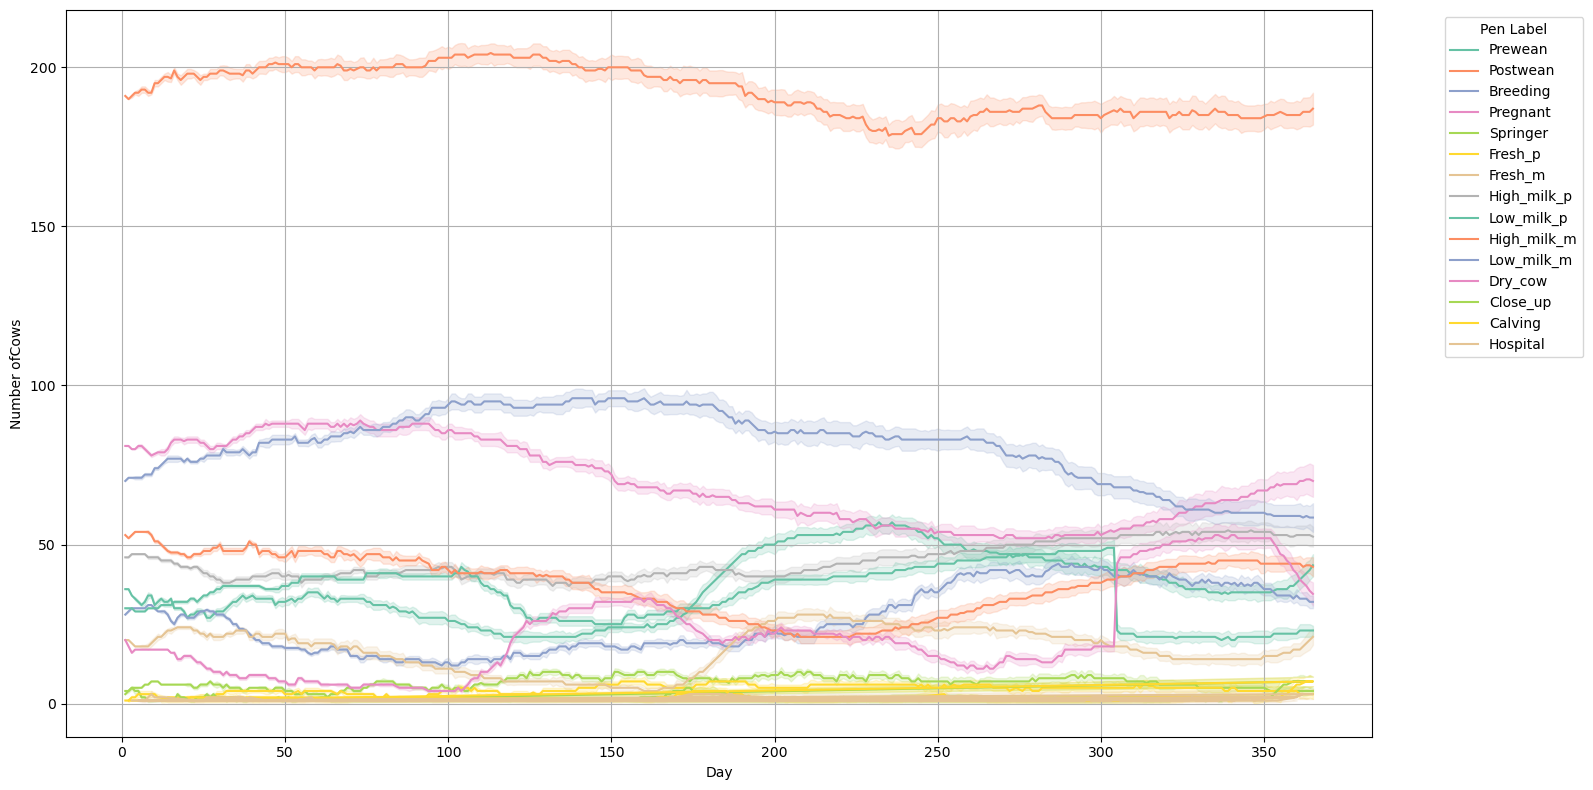

In [23]:
palette = sns.color_palette('Set2', n_colors=15) 
color_dict = {label: palette[i % len(palette)] for i, label in enumerate(ordered_labels)}

plt.figure(figsize=(16, 8))
for pen, label in zip(ordered_pens, ordered_labels):
    group = summary_df[summary_df['pen'] == pen]
    if not group.empty:
        color = color_dict.get(label, 'gray')
        plt.plot(group['day'], group['median'], label=label, color=color)
        plt.fill_between(group['day'],
                         group['median'] - group['iqr'] / 2,
                         group['median'] + group['iqr'] / 2,
                         color=color, alpha=0.2)

plt.xlabel('Day')
plt.ylabel('Number ofCows')
# Legend: Only show labels in pen order
handles, legend_labels = plt.gca().get_legend_handles_labels()
# Reorder legend according to ordered_labels
legend_order = [ordered_labels.index(lbl) for lbl in legend_labels if lbl in ordered_labels]
handles = [handles[i] for i in np.argsort(legend_order)]
labels = [legend_labels[i] for i in np.argsort(legend_order)]
plt.legend(handles, labels, title='Pen Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()  
plt.tight_layout()
plt.savefig("pen_counts2.tiff", dpi = 300)
plt.show()

In [86]:
seir_summary_list2 = []
for df in sim_list2['seir_history']:
    # Only include alive cows
    df_alive = df[df['alive']]
    # Count per state per day
    counts = df_alive.groupby(['day', 'state']).size().reset_index(name='count')
    seir_summary_list2.append(counts)

seir_summary_list2[1]

,day,state,count
0,1,Exposed,2
1,1,Infectious,10
2,1,Susceptible,571
3,2,Exposed,3
4,2,Infectious,9
...,...,...,...
1328,364,Susceptible,424
1329,365,Exposed,3
1330,365,Infectious,6
1331,365,Recovered,160


In [87]:
all_counts2 = pd.concat(seir_summary_list2, keys=range(len(seir_summary_list2)), names=['sim', 'idx'])
# For easier aggregation:
pivoted2 = all_counts2.pivot_table(index=['day', 'state'], columns='sim', values='count', fill_value=0)

# Compute stats for each state and day
results2 = []
for (day, state), vals in pivoted2.iterrows():
    med = np.median(vals)
    q1 = np.percentile(vals, 25)
    q3 = np.percentile(vals, 75)
    iqr = q3 - q1
    results2.append({'day': day, 'state': state, 'median': med, 'iqr': iqr})
states_summary2 = pd.DataFrame(results2)
states_summary2.head()

,day,state,median,iqr
0,1,Exposed,3.0,2.0
1,1,Infectious,10.0,0.0
2,1,Susceptible,569.0,2.0
3,2,Exposed,6.0,4.0
4,2,Infectious,10.0,1.0


In [89]:
states_summary2.to_csv("farm2_seir.csv", index = False)

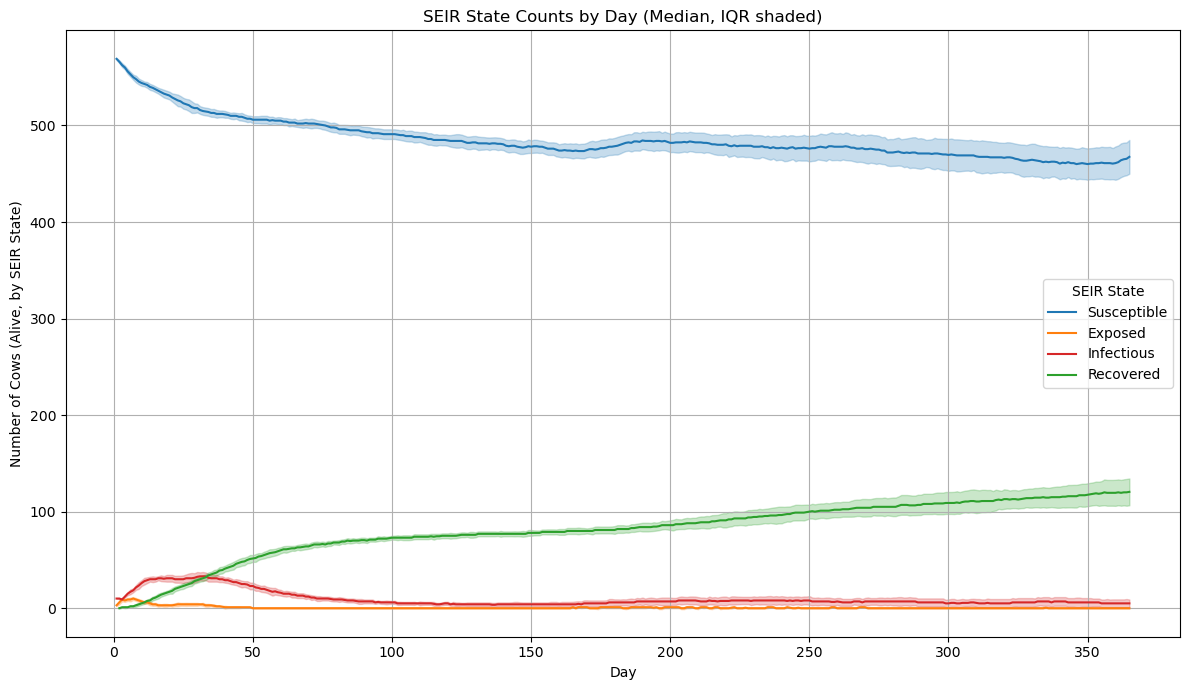

In [26]:
state_palette = {'Susceptible': '#1f77b4', 'Exposed': '#ff7f0e', 'Infectious': '#d62728', 'Recovered': '#2ca02c'}

plt.figure(figsize=(12, 7))
for state in ['Susceptible', 
              'Exposed',
              'Infectious',
              'Recovered']:
    g = states_summary[states_summary['state'] == state]
    g = g.sort_values('day')
    plt.plot(g['day'], g['median'], label=state, color=state_palette.get(state))
    plt.fill_between(g['day'],
                     g['median'] - g['iqr'] / 2,
                     g['median'] + g['iqr'] / 2,
                     color=state_palette.get(state, 'gray'),
                     alpha=0.25)

plt.xlabel('Day')
plt.ylabel('Number of Cows (Alive, by SEIR State)')
plt.title('SEIR State Counts by Day (Median, IQR shaded)')
plt.legend(title='SEIR State')
plt.grid()  
plt.tight_layout()
plt.show()

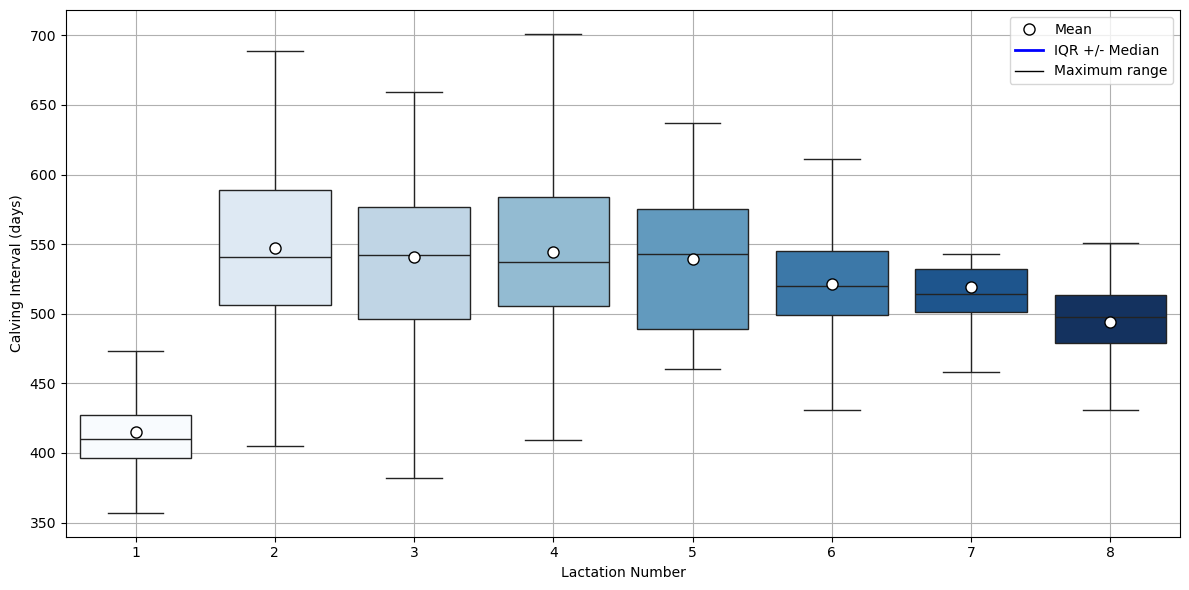

In [90]:
from matplotlib.lines import Line2D

# Concatenate calving intervals, as before
ci_lactation_list2 = []
for df in sim_list2['calving_intervals']:
    valid = df[df['calv_interval'].notnull()]
    ci_lactation_list2.append(valid[['lactation_number', 'calv_interval']])

all_ci2 = pd.concat(ci_lactation_list2, ignore_index=True)

# Remove lactation_number == 0
all_ci2 = all_ci2[all_ci2['lactation_number'] != 0]

# Plot boxplots
plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    x='lactation_number',
    y='calv_interval',
    hue = 'lactation_number',
    palette = 'Blues',
    data=all_ci2,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", 
               "markeredgecolor":"black", "markersize":8},
    showfliers=False
)

plt.xlabel('Lactation Number')
plt.ylabel('Calving Interval (days)')

# Custom legend handles:
mean_legend = Line2D([0], [0], marker='o', color='w',
                      markerfacecolor='white', markeredgecolor='black',
                      markersize=8, label='Mean')
box_legend = Line2D([0], [0], color='blue', lw=2, label='IQR +/- Median')
whisker_legend = Line2D([0], [0], color='black', lw=1, label='Maximum range')

# Show only custom symbols (means, box, whisker), because lactation numbers are x-tick labels
plt.legend(handles=[mean_legend, box_legend, whisker_legend], 
           loc='best')
plt.grid()  
plt.tight_layout()
plt.savefig("calving_intervals2.tiff", dpi = 300)
plt.show()


In [91]:
all_ci2.to_csv("farm2_ci.csv", index = False)

In [28]:
sim_list2['days_in_milk'][0]

,cow_id,lactation_number,days_in_milk
0,6,8,327
1,71,7,75
2,83,7,19
3,86,8,486
4,253,6,512
...,...,...,...
575,2615,0,0
576,2616,0,0
577,2617,0,0
578,2618,0,0


In [29]:
sim_list2['lactation_summary'][0]

,cow_id,max_lactation,days_in_milk_per_lactation
0,6,8,"{0: 0, 1: 329, 2: 434, 3: 381, 4: 342, 5: 388,..."
1,10,8,"{0: 0, 1: 347, 2: 405, 3: 398, 4: 407, 5: 351,..."
2,60,8,"{0: 0, 1: 307, 2: 428, 3: 524, 4: 408, 5: 517,..."
3,71,7,"{0: 0, 1: 307, 2: 459, 3: 430, 4: 351, 5: 479,..."
4,83,7,"{0: 0, 1: 307, 2: 386, 3: 427, 4: 430, 5: 496,..."
...,...,...,...
788,2615,0,{}
789,2616,0,{}
790,2617,0,{}
791,2618,0,{}


In [92]:
all_lact_summary2 = []
for df in sim_list2['lactation_summary']:
    valid = df[df['max_lactation'] != 0]
    avg_lact = valid['max_lactation'].mean()
    std_lact = valid['max_lactation'].std()
    dim = []
    for dd in valid['days_in_milk_per_lactation']:
        for k, v in dd.items():
            # Exclude lactation 0 if present (usually dry-off)
            if k != 0:
                dim.append(v)
    if dim:
        median_dim = np.median(dim)
        q1_dim = np.percentile(dim, 25)
        q3_dim = np.percentile(dim, 75)
        iqr_dim = q3_dim - q1_dim
    else:
        median_dim, iqr_dim = np.nan, np.nan
    
    all_lact_summary2.append({
        'average_lactation_number': avg_lact,
        'stddev_lactation_number': std_lact,
        'median_days_in_milk': median_dim,
        'iqr_days_in_milk': iqr_dim
    })

summary_lact2 = pd.DataFrame(all_lact_summary2)
# print(summary_df.describe())
summary_lact2

,average_lactation_number,stddev_lactation_number,median_days_in_milk,iqr_days_in_milk
0,2.368116,1.738960,366.0,100.25
1,2.462462,1.770560,366.0,99.50
2,2.375367,1.720083,366.0,102.00
3,2.383721,1.735707,367.0,98.25
4,2.383481,1.727045,366.0,99.00
...,...,...,...,...
95,2.376812,1.729544,367.0,100.00
96,2.385507,1.748527,367.0,100.50
97,2.395954,1.738527,367.0,99.00
98,2.385294,1.719682,367.0,97.50


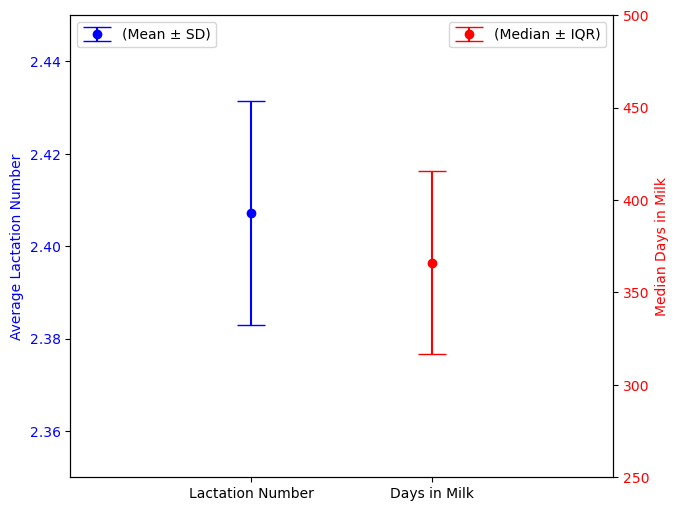

In [93]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(7, 6))

x1 = 0.4
x2 = 0.6

N = len(summary_lact2)

# Lactation number
lat_mean = summary_lact2['average_lactation_number'].mean()
lat_sem = summary_lact2['average_lactation_number'].std()
lat_ci95 = 1 * lat_sem
lat_max = max(lat_mean + lat_ci95, summary_lact2['average_lactation_number'].max())
ax1.errorbar(
    x=x1, y=lat_mean, yerr=lat_ci95,
    fmt='o', color='blue', capsize=10, label='(Mean ± SD)'
)
ax1.set_ylabel('Average Lactation Number', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Expand y-limits to 150%
ax1.set_ylim(2.35, 2.45)
# Days in milk
dim_median = summary_lact2['median_days_in_milk'].median()
dim_iqr = summary_lact2['iqr_days_in_milk'].median()
dim_max = max(dim_median + (dim_iqr / 2), summary_lact2['median_days_in_milk'].max())
ax2 = ax1.twinx()
ax2.errorbar(
    x=x2, y=dim_median, yerr=dim_iqr/2,
    fmt='o', color='red', capsize=10, label='(Median ± IQR)'
)
ax2.set_ylabel('Median Days in Milk', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Expand y-limits to 150%
ax2.set_ylim(250, 500)

# Center x-ticks
ax1.set_xticks([x1, x2])
ax1.set_xticklabels(['Lactation Number', 'Days in Milk'])
ax1.set_xlim(0.2, 0.8)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# plt.tight_layout()
plt.savefig("dim_lact2.tiff", dpi = 300)
plt.show()


In [95]:
summary_lact2.to_csv("farm2_lact_sum.csv", index = False)

# Farm 3

In [32]:
sim_list3 = sim_mod.run_main_simulation(burn_in_farm_state = farm3['burn_in_farm'], 
                                      merge_dwell_df = sim_mod.merge_dwell, 
                                      ndays = 365, 
                                      burn_in_days = 3650, 
                                      initial_infected = farm3['initial_infected'], 
                                      transmission_rate = farm3['T'], 
                                      recovery_rate = farm3['R'], 
                                      incubation_period = farm3['Incubation'], 
                                      pens_to_mask=['Pen1', 'Pen2', 'Pen3', 'Pen4'],
                                      num_simulations=100)

In [97]:
summary_list3 = []
for df in sim_list3['seir_history']:
    alive_counts = (
        df[df['alive']]
        .groupby(['day', 'pen'])
        .size()
        .reset_index(name='count')
    )
    summary_list3.append(alive_counts)

# Concatenate and make a multi-indexed DataFrame
all_runs3 = pd.concat(summary_list3, keys=range(len(summary_list3)), names=['sim', 'idx'])

# Pivot to have sims as columns (for aggregation)
all_runs_pivot3 = all_runs3.pivot_table(index=['day', 'pen'], columns='sim', values='count').fillna(0)

day_pen3 = all_runs3[['day', 'pen']].drop_duplicates()

# For each combination, get the counts across all sims
results3 = []
for _, row in day_pen3.iterrows():
    day = row['day']
    pen = row['pen']
    # print(f"Pen: {pen}, Day: {day}, Counts: {vals}")
    # All runs for this day/pen
    vals = all_runs3[(all_runs3['day'] == day) & (all_runs3['pen'] == pen)]['count'].values
    median = np.median(vals)
    q1 = np.percentile(vals, 25)
    q3 = np.percentile(vals, 75)
    iqr = q3 - q1
    results3.append({'pen': pen, 'day': day, 'median': median, 'iqr': iqr})

summary_df3 = pd.DataFrame(results3)

summary_df3

,pen,day,median,iqr
0,Pen1,1,169.0,0.0
1,Pen10,1,210.0,0.0
2,Pen11,1,339.0,1.0
3,Pen12,1,75.0,0.0
4,Pen13,1,6.0,0.0
...,...,...,...,...
5470,Pen14,290,4.5,3.0
5471,Pen14,291,5.0,3.0
5472,Pen14,314,5.0,4.0
5473,Pen15,316,5.0,3.0


In [34]:
pen_labels = pd.DataFrame({'pen': [f'Pen{i}' for i in range(1, 16)],
                        'label' : ["Prewean",
                                  "Postwean",
                                  "Breeding",
                                  "Pregnant",
                                  "Springer",
                                  "Fresh_p",
                                  "Fresh_m",
                                  "High_milk_p",
                                  "Low_milk_p",
                                  "High_milk_m",
                                  "Low_milk_m",
                                  "Dry_cow",
                                  "Close_up",
                                  "Calving",
                                  "Hospital"]})
pen_labels

,pen,label
0,Pen1,Prewean
1,Pen2,Postwean
2,Pen3,Breeding
3,Pen4,Pregnant
4,Pen5,Springer
5,Pen6,Fresh_p
6,Pen7,Fresh_m
7,Pen8,High_milk_p
8,Pen9,Low_milk_p
9,Pen10,High_milk_m


In [98]:
summary_df3['pen'] = summary_df3['pen'].astype(str)
ordered_pens = [f'Pen{i}' for i in range(1, 15+1)]

# Get label mapping from pen_labels (assumes 'pen'/'label' in pen_labels)
pen_to_label = dict(zip(pen_labels['pen'], pen_labels['label']))
ordered_labels = [pen_to_label[pen] for pen in ordered_pens]


In [100]:
summary_df3.to_csv("farm3_pen_counts.csv", index = False)

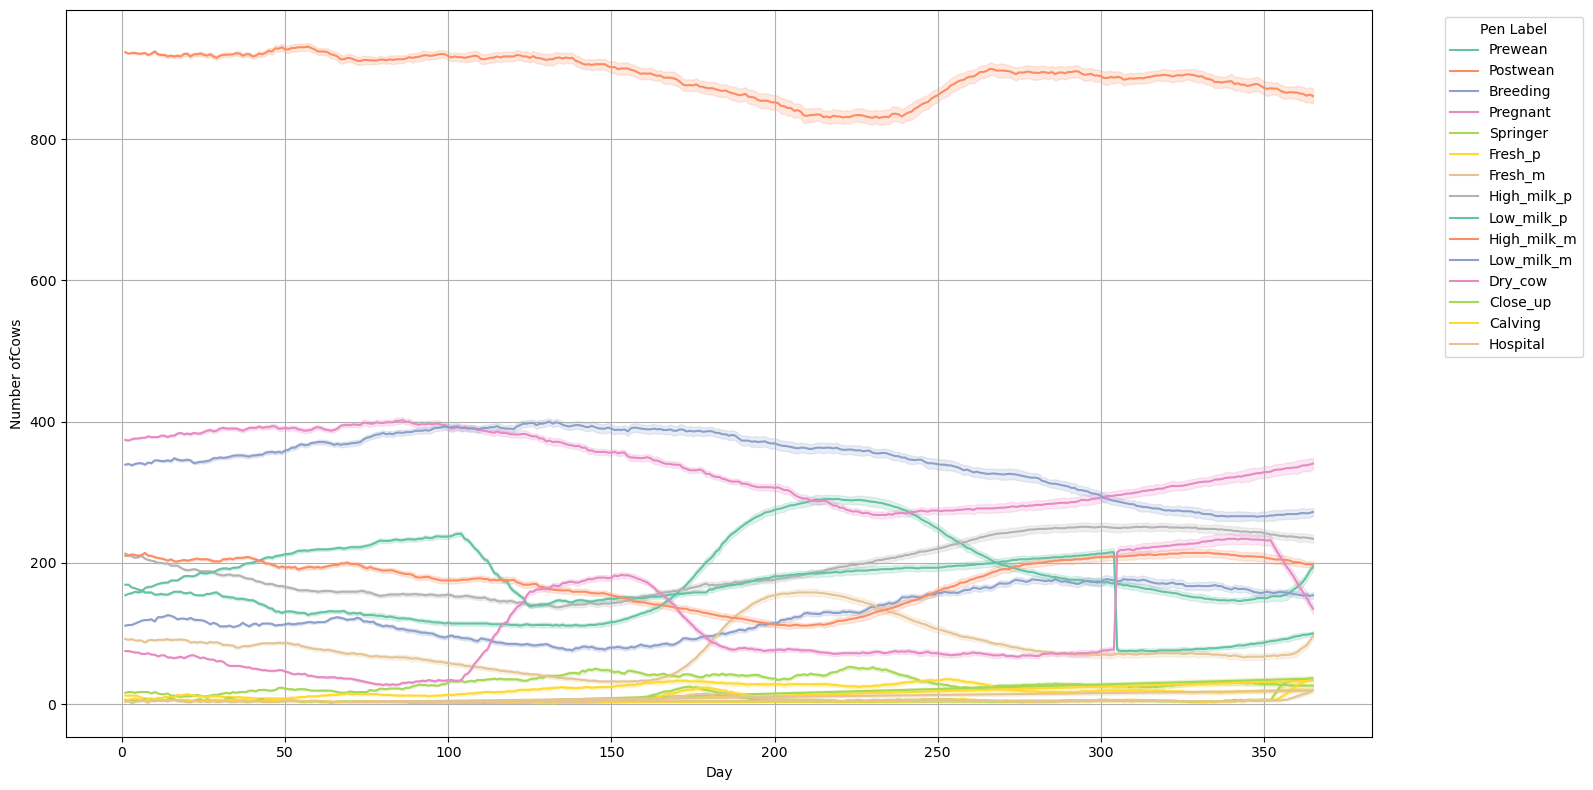

In [36]:
palette = sns.color_palette('Set2', n_colors=15) 
color_dict = {label: palette[i % len(palette)] for i, label in enumerate(ordered_labels)}

plt.figure(figsize=(16, 8))
for pen, label in zip(ordered_pens, ordered_labels):
    group = summary_df3[summary_df3['pen'] == pen]
    if not group.empty:
        color = color_dict.get(label, 'gray')
        plt.plot(group['day'], group['median'], label=label, color=color)
        plt.fill_between(group['day'],
                         group['median'] - group['iqr'] / 2,
                         group['median'] + group['iqr'] / 2,
                         color=color, alpha=0.2)

plt.xlabel('Day')
plt.ylabel('Number ofCows')
# Legend: Only show labels in pen order
handles, legend_labels = plt.gca().get_legend_handles_labels()
# Reorder legend according to ordered_labels
legend_order = [ordered_labels.index(lbl) for lbl in legend_labels if lbl in ordered_labels]
handles = [handles[i] for i in np.argsort(legend_order)]
labels = [legend_labels[i] for i in np.argsort(legend_order)]
plt.legend(handles, labels, title='Pen Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()  
plt.tight_layout()
plt.savefig("pen_counts3.tiff", dpi = 300)
plt.show()

In [101]:
seir_summary_list3 = []
for df in sim_list3['seir_history']:
    # Only include alive cows
    df_alive = df[df['alive']]
    # Count per state per day
    counts = df_alive.groupby(['day', 'state']).size().reset_index(name='count')
    seir_summary_list3.append(counts)

seir_summary_list3[1]

,day,state,count
0,1,Exposed,23
1,1,Infectious,10
2,1,Susceptible,2667
3,2,Exposed,43
4,2,Infectious,9
...,...,...,...
1427,364,Susceptible,2085
1428,365,Exposed,6
1429,365,Infectious,14
1430,365,Recovered,578


In [102]:
all_counts3 = pd.concat(seir_summary_list3, keys=range(len(seir_summary_list3)), names=['sim', 'idx'])
# For easier aggregation:
pivoted3 = all_counts3.pivot_table(index=['day', 'state'], columns='sim', values='count', fill_value=0)

# Compute stats for each state and day
results3 = []
for (day, state), vals in pivoted3.iterrows():
    med = np.median(vals)
    q1 = np.percentile(vals, 25)
    q3 = np.percentile(vals, 75)
    iqr = q3 - q1
    results3.append({'day': day, 'state': state, 'median': med, 'iqr': iqr})
states_summary3 = pd.DataFrame(results3)
states_summary3.head()

,day,state,median,iqr
0,1,Exposed,19.0,4.00
1,1,Infectious,10.0,0.00
2,1,Susceptible,2672.0,4.00
3,2,Exposed,34.0,6.25
4,2,Infectious,9.0,1.00


In [104]:
states_summary3.to_csv("farm3_seir.csv", index = False)

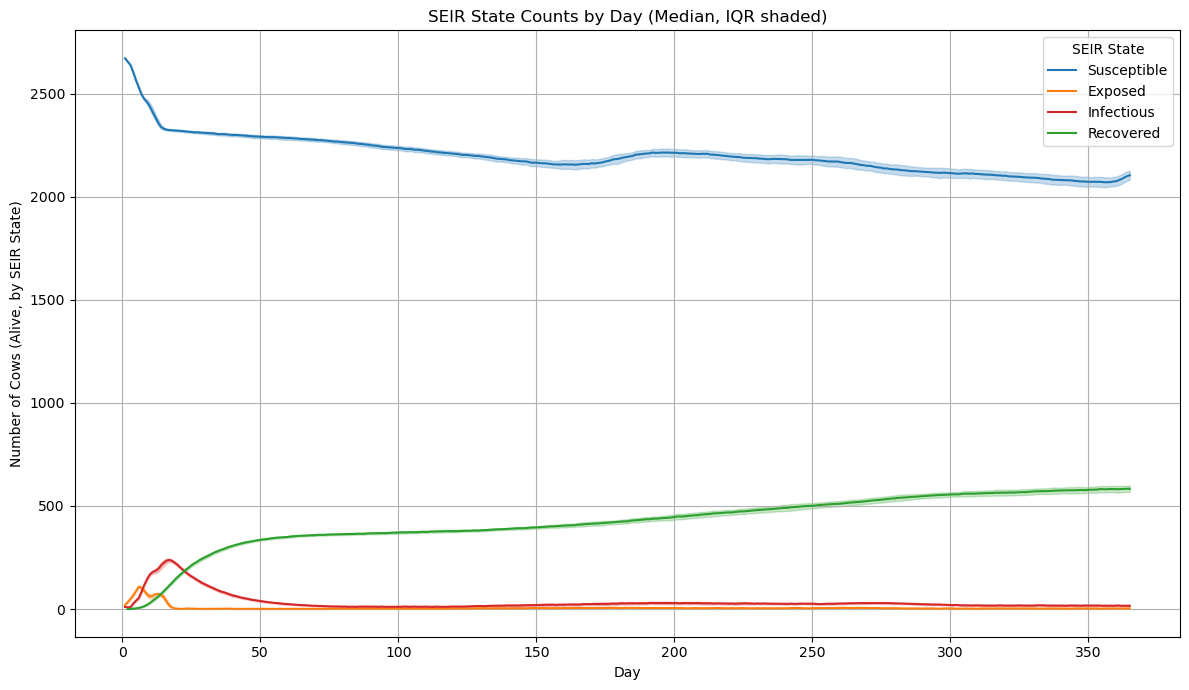

In [39]:
state_palette = {'Susceptible': '#1f77b4', 'Exposed': '#ff7f0e', 'Infectious': '#d62728', 'Recovered': '#2ca02c'}

plt.figure(figsize=(12, 7))
for state in ['Susceptible', 
              'Exposed',
              'Infectious',
              'Recovered']:
    g = states_summary[states_summary['state'] == state]
    g = g.sort_values('day')
    plt.plot(g['day'], g['median'], label=state, color=state_palette.get(state))
    plt.fill_between(g['day'],
                     g['median'] - g['iqr'] / 2,
                     g['median'] + g['iqr'] / 2,
                     color=state_palette.get(state, 'gray'),
                     alpha=0.25)

plt.xlabel('Day')
plt.ylabel('Number of Cows (Alive, by SEIR State)')
plt.title('SEIR State Counts by Day (Median, IQR shaded)')
plt.legend(title='SEIR State')
plt.grid()  
plt.tight_layout()
plt.show()

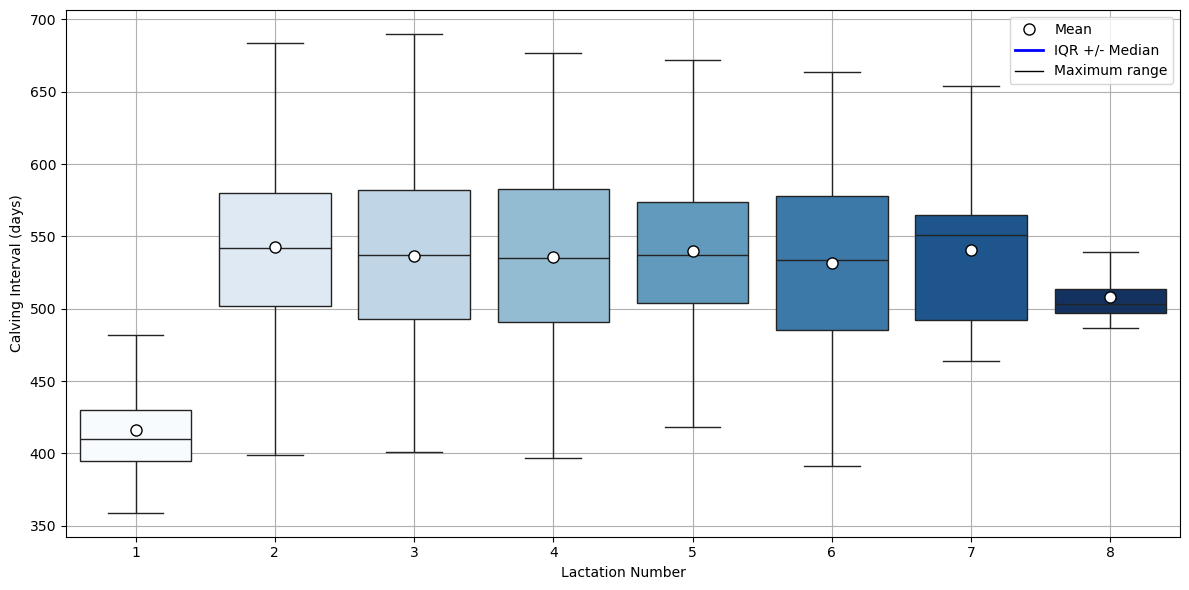

In [105]:
from matplotlib.lines import Line2D

# Concatenate calving intervals, as before
ci_lactation_list3 = []
for df in sim_list3['calving_intervals']:
    valid = df[df['calv_interval'].notnull()]
    ci_lactation_list3.append(valid[['lactation_number', 'calv_interval']])

all_ci3 = pd.concat(ci_lactation_list3, ignore_index=True)

# Remove lactation_number == 0
all_ci3 = all_ci3[all_ci3['lactation_number'] != 0]

# Plot boxplots
plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    x='lactation_number',
    y='calv_interval',
    hue = 'lactation_number',
    palette = 'Blues',
    data=all_ci3,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", 
               "markeredgecolor":"black", "markersize":8},
    showfliers=False
)

plt.xlabel('Lactation Number')
plt.ylabel('Calving Interval (days)')

# Custom legend handles:
mean_legend = Line2D([0], [0], marker='o', color='w',
                      markerfacecolor='white', markeredgecolor='black',
                      markersize=8, label='Mean')
box_legend = Line2D([0], [0], color='blue', lw=2, label='IQR +/- Median')
whisker_legend = Line2D([0], [0], color='black', lw=1, label='Maximum range')

# Show only custom symbols (means, box, whisker), because lactation numbers are x-tick labels
plt.legend(handles=[mean_legend, box_legend, whisker_legend], 
           loc='best')
plt.grid()  
plt.tight_layout()
plt.savefig("calving_intervals3.tiff", dpi = 300)
plt.show()


In [106]:
all_ci3.to_csv("farm3_ci.csv", index = False)

In [41]:
sim_list3['days_in_milk'][0]

,cow_id,lactation_number,days_in_milk
0,108,8,482
1,140,7,404
2,149,6,439
3,177,6,473
4,271,7,60
...,...,...,...
2720,11974,0,0
2721,11975,0,0
2722,11976,0,0
2723,11977,0,0


In [42]:
sim_list3['lactation_summary'][0]

,cow_id,max_lactation,days_in_milk_per_lactation
0,67,7,"{0: 0, 1: 307, 2: 378, 3: 390, 4: 401, 5: 446,..."
1,108,8,"{0: 0, 1: 323, 2: 395, 3: 360, 4: 460, 5: 352,..."
2,140,7,"{0: 0, 1: 322, 2: 452, 3: 498, 4: 499, 5: 475,..."
3,149,6,"{0: 0, 1: 331, 2: 510, 3: 413, 4: 491, 5: 392}"
4,177,6,"{0: 0, 1: 348, 2: 391, 3: 391, 4: 348, 5: 539}"
...,...,...,...
3668,11974,0,{}
3669,11975,0,{}
3670,11976,0,{}
3671,11977,0,{}


In [107]:
all_lact_summary3 = []
for df in sim_list3['lactation_summary']:
    valid = df[df['max_lactation'] != 0]
    avg_lact = valid['max_lactation'].mean()
    std_lact = valid['max_lactation'].std()
    dim = []
    for dd in valid['days_in_milk_per_lactation']:
        for k, v in dd.items():
            # Exclude lactation 0 if present (usually dry-off)
            if k != 0:
                dim.append(v)
    if dim:
        median_dim = np.median(dim)
        q1_dim = np.percentile(dim, 25)
        q3_dim = np.percentile(dim, 75)
        iqr_dim = q3_dim - q1_dim
    else:
        median_dim, iqr_dim = np.nan, np.nan
    
    all_lact_summary3.append({
        'average_lactation_number': avg_lact,
        'stddev_lactation_number': std_lact,
        'median_days_in_milk': median_dim,
        'iqr_days_in_milk': iqr_dim
    })

summary_lact3 = pd.DataFrame(all_lact_summary3)
# print(summary_df.describe())
summary_lact3

,average_lactation_number,stddev_lactation_number,median_days_in_milk,iqr_days_in_milk
0,2.356634,1.639161,365.0,100.0
1,2.366775,1.646874,365.0,100.0
2,2.377049,1.637046,365.5,101.0
3,2.351036,1.636377,364.0,101.0
4,2.345655,1.632483,364.0,99.0
...,...,...,...,...
95,2.363754,1.640953,366.0,101.0
96,2.372459,1.638698,366.0,101.0
97,2.349288,1.637621,365.0,99.0
98,2.350968,1.631096,364.0,99.0


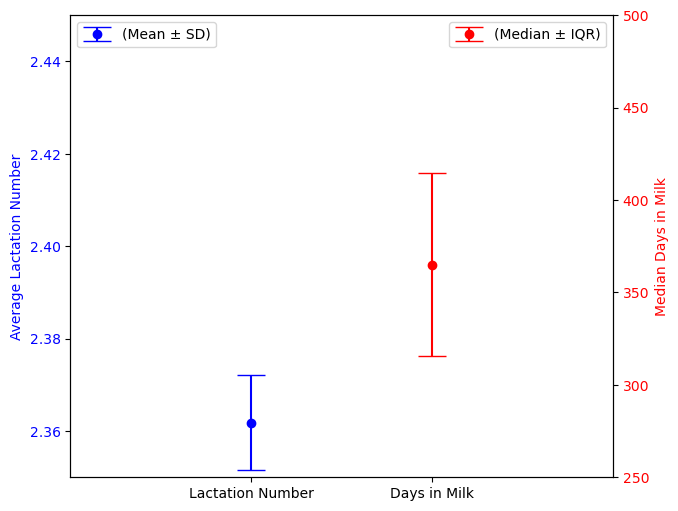

In [50]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(7, 6))

x1 = 0.4
x2 = 0.6

N = len(summary_df)

# Lactation number
lat_mean = summary_df['average_lactation_number'].mean()
lat_sem = summary_df['average_lactation_number'].std()
lat_ci95 = 1 * lat_sem
lat_max = max(lat_mean + lat_ci95, summary_df['average_lactation_number'].max())
ax1.errorbar(
    x=x1, y=lat_mean, yerr=lat_ci95,
    fmt='o', color='blue', capsize=10, label='(Mean ± SD)'
)
ax1.set_ylabel('Average Lactation Number', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Expand y-limits to 150%
ax1.set_ylim(2.35, 2.45)
# Days in milk
dim_median = summary_df['median_days_in_milk'].median()
dim_iqr = summary_df['iqr_days_in_milk'].median()
dim_max = max(dim_median + (dim_iqr / 2), summary_df['median_days_in_milk'].max())
ax2 = ax1.twinx()
ax2.errorbar(
    x=x2, y=dim_median, yerr=dim_iqr/2,
    fmt='o', color='red', capsize=10, label='(Median ± IQR)'
)
ax2.set_ylabel('Median Days in Milk', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Expand y-limits to 150%
ax2.set_ylim(250, 500)

# Center x-ticks
ax1.set_xticks([x1, x2])
ax1.set_xticklabels(['Lactation Number', 'Days in Milk'])
ax1.set_xlim(0.2, 0.8)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# plt.tight_layout()
plt.savefig("dim_lact3.tiff", dpi = 300)
plt.show()


In [109]:
summary_lact3.to_csv("farm3_lact_sum.csv", index = False)

# Farm 4

In [51]:
sim_list4 = sim_mod.run_main_simulation(burn_in_farm_state = farm4['burn_in_farm'], 
                                      merge_dwell_df = sim_mod.merge_dwell, 
                                      ndays = 365, 
                                      burn_in_days = 3650, 
                                      initial_infected = farm4['initial_infected'], 
                                      transmission_rate = farm4['T'], 
                                      recovery_rate = farm4['R'], 
                                      incubation_period = farm4['Incubation'], 
                                      pens_to_mask=['Pen1', 'Pen2', 'Pen3', 'Pen4'],
                                      num_simulations=100)

In [110]:
summary_list4 = []
for df in sim_list4['seir_history']:
    alive_counts = (
        df[df['alive']]
        .groupby(['day', 'pen'])
        .size()
        .reset_index(name='count')
    )
    summary_list4.append(alive_counts)

# Concatenate and make a multi-indexed DataFrame
all_runs4 = pd.concat(summary_list4, keys=range(len(summary_list4)), names=['sim', 'idx'])

# Pivot to have sims as columns (for aggregation)
all_runs_pivot4 = all_runs4.pivot_table(index=['day', 'pen'], columns='sim', values='count').fillna(0)

day_pen4 = all_runs4[['day', 'pen']].drop_duplicates()

# For each combination, get the counts across all sims
results4 = []
for _, row in day_pen4.iterrows():
    day = row['day']
    pen = row['pen']
    # print(f"Pen: {pen}, Day: {day}, Counts: {vals}")
    # All runs for this day/pen
    vals = all_runs4[(all_runs4['day'] == day) & (all_runs4['pen'] == pen)]['count'].values
    median = np.median(vals)
    q1 = np.percentile(vals, 25)
    q3 = np.percentile(vals, 75)
    iqr = q3 - q1
    results4.append({'pen': pen, 'day': day, 'median': median, 'iqr': iqr})

summary_df4 = pd.DataFrame(results4)

summary_df4

,pen,day,median,iqr
0,Pen1,1,150.0,0.0
1,Pen10,1,182.0,0.0
2,Pen11,1,328.0,1.0
3,Pen12,1,61.0,0.0
4,Pen13,1,6.0,0.0
...,...,...,...,...
5470,Pen13,141,2.0,1.0
5471,Pen14,142,2.0,1.0
5472,Pen14,143,2.0,1.0
5473,Pen14,144,2.0,1.0


In [53]:
pen_labels = pd.DataFrame({'pen': [f'Pen{i}' for i in range(1, 16)],
                        'label' : ["Prewean",
                                  "Postwean",
                                  "Breeding",
                                  "Pregnant",
                                  "Springer",
                                  "Fresh_p",
                                  "Fresh_m",
                                  "High_milk_p",
                                  "Low_milk_p",
                                  "High_milk_m",
                                  "Low_milk_m",
                                  "Dry_cow",
                                  "Close_up",
                                  "Calving",
                                  "Hospital"]})
pen_labels

,pen,label
0,Pen1,Prewean
1,Pen2,Postwean
2,Pen3,Breeding
3,Pen4,Pregnant
4,Pen5,Springer
5,Pen6,Fresh_p
6,Pen7,Fresh_m
7,Pen8,High_milk_p
8,Pen9,Low_milk_p
9,Pen10,High_milk_m


In [111]:
summary_df4['pen'] = summary_df4['pen'].astype(str)
ordered_pens = [f'Pen{i}' for i in range(1, 15+1)]

# Get label mapping from pen_labels (assumes 'pen'/'label' in pen_labels)
pen_to_label = dict(zip(pen_labels['pen'], pen_labels['label']))
ordered_labels = [pen_to_label[pen] for pen in ordered_pens]


In [113]:
summary_df4.to_csv("farm4_pen_counts.csv", index = False)

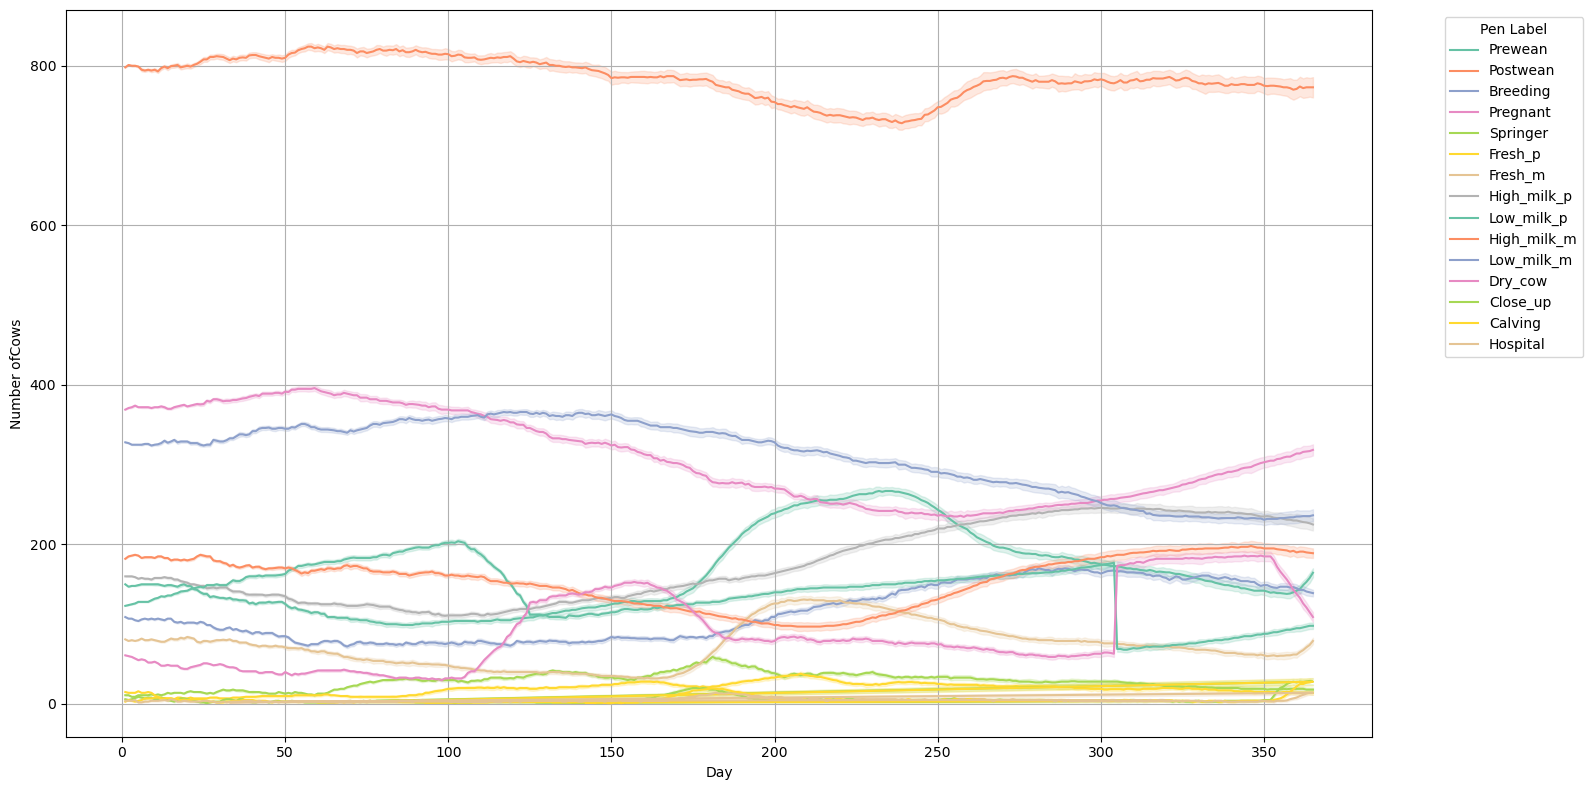

In [55]:
palette = sns.color_palette('Set2', n_colors=15) 
color_dict = {label: palette[i % len(palette)] for i, label in enumerate(ordered_labels)}

plt.figure(figsize=(16, 8))
for pen, label in zip(ordered_pens, ordered_labels):
    group = summary_df[summary_df['pen'] == pen]
    if not group.empty:
        color = color_dict.get(label, 'gray')
        plt.plot(group['day'], group['median'], label=label, color=color)
        plt.fill_between(group['day'],
                         group['median'] - group['iqr'] / 2,
                         group['median'] + group['iqr'] / 2,
                         color=color, alpha=0.2)

plt.xlabel('Day')
plt.ylabel('Number ofCows')
# Legend: Only show labels in pen order
handles, legend_labels = plt.gca().get_legend_handles_labels()
# Reorder legend according to ordered_labels
legend_order = [ordered_labels.index(lbl) for lbl in legend_labels if lbl in ordered_labels]
handles = [handles[i] for i in np.argsort(legend_order)]
labels = [legend_labels[i] for i in np.argsort(legend_order)]
plt.legend(handles, labels, title='Pen Label', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()  
plt.tight_layout()
plt.savefig("pen_counts4.tiff", dpi = 300)
plt.show()

In [114]:
seir_summary_list4 = []
for df in sim_list4['seir_history']:
    # Only include alive cows
    df_alive = df[df['alive']]
    # Count per state per day
    counts = df_alive.groupby(['day', 'state']).size().reset_index(name='count')
    seir_summary_list4.append(counts)

seir_summary_list4[1]

,day,state,count
0,1,Exposed,3
1,1,Infectious,1
2,1,Susceptible,2392
3,2,Exposed,7
4,2,Infectious,1
...,...,...,...
1434,364,Susceptible,1387
1435,365,Exposed,1
1436,365,Infectious,23
1437,365,Recovered,981


In [115]:
all_counts4 = pd.concat(seir_summary_list4, keys=range(len(seir_summary_list4)), names=['sim', 'idx'])
# For easier aggregation:
pivoted4 = all_counts4.pivot_table(index=['day', 'state'], columns='sim', values='count', fill_value=0)

# Compute stats for each state and day
results4 = []
for (day, state), vals in pivoted4.iterrows():
    med = np.median(vals)
    q1 = np.percentile(vals, 25)
    q3 = np.percentile(vals, 75)
    iqr = q3 - q1
    results4.append({'day': day, 'state': state, 'median': med, 'iqr': iqr})
states_summary4 = pd.DataFrame(results4)
states_summary4.head()

,day,state,median,iqr
0,1,Exposed,2.0,1.00
1,1,Infectious,1.0,0.00
2,1,Susceptible,2394.0,3.00
3,2,Exposed,5.0,2.25
4,2,Infectious,1.0,0.00


In [117]:
states_summary4.to_csv("farm4_seir.csv", index = False)

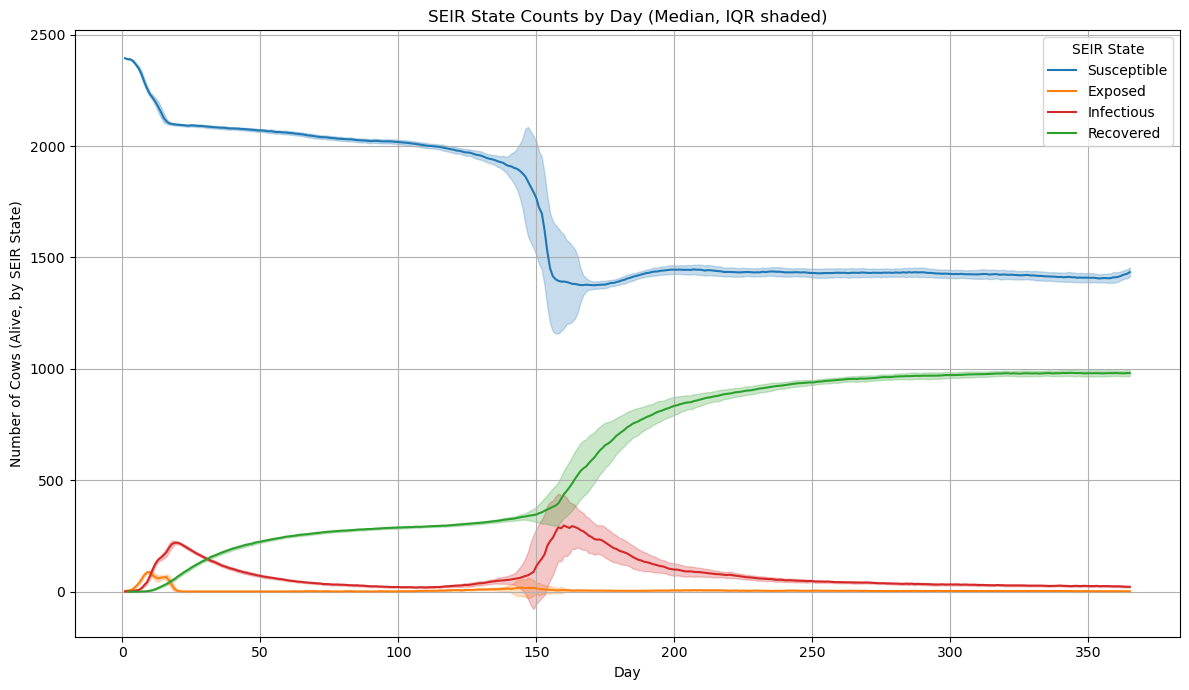

In [58]:
state_palette = {'Susceptible': '#1f77b4', 'Exposed': '#ff7f0e', 'Infectious': '#d62728', 'Recovered': '#2ca02c'}

plt.figure(figsize=(12, 7))
for state in ['Susceptible', 
              'Exposed',
              'Infectious',
              'Recovered']:
    g = states_summary[states_summary['state'] == state]
    g = g.sort_values('day')
    plt.plot(g['day'], g['median'], label=state, color=state_palette.get(state))
    plt.fill_between(g['day'],
                     g['median'] - g['iqr'] / 2,
                     g['median'] + g['iqr'] / 2,
                     color=state_palette.get(state, 'gray'),
                     alpha=0.25)

plt.xlabel('Day')
plt.ylabel('Number of Cows (Alive, by SEIR State)')
plt.title('SEIR State Counts by Day (Median, IQR shaded)')
plt.legend(title='SEIR State')
plt.grid()  
plt.tight_layout()
plt.show()

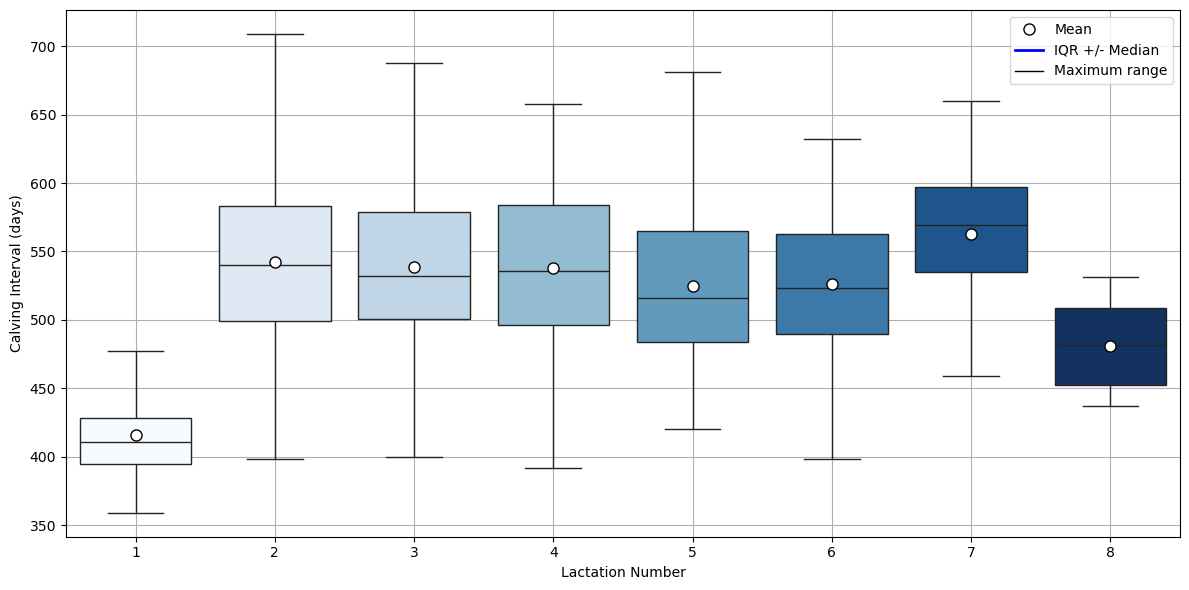

In [118]:
from matplotlib.lines import Line2D

# Concatenate calving intervals, as before
ci_lactation_list4 = []
for df in sim_list4['calving_intervals']:
    valid = df[df['calv_interval'].notnull()]
    ci_lactation_list4.append(valid[['lactation_number', 'calv_interval']])

all_ci4 = pd.concat(ci_lactation_list4, ignore_index=True)

# Remove lactation_number == 0
all_ci4 = all_ci4[all_ci4['lactation_number'] != 0]

# Plot boxplots
plt.figure(figsize=(12, 6))
ax = sns.boxplot(
    x='lactation_number',
    y='calv_interval',
    hue = 'lactation_number',
    palette = 'Blues',
    data=all_ci4,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", 
               "markeredgecolor":"black", "markersize":8},
    showfliers=False
)

plt.xlabel('Lactation Number')
plt.ylabel('Calving Interval (days)')

# Custom legend handles:
mean_legend = Line2D([0], [0], marker='o', color='w',
                      markerfacecolor='white', markeredgecolor='black',
                      markersize=8, label='Mean')
box_legend = Line2D([0], [0], color='blue', lw=2, label='IQR +/- Median')
whisker_legend = Line2D([0], [0], color='black', lw=1, label='Maximum range')

# Show only custom symbols (means, box, whisker), because lactation numbers are x-tick labels
plt.legend(handles=[mean_legend, box_legend, whisker_legend], 
           loc='best')
plt.grid()  
plt.tight_layout()
plt.savefig("calving_intervals4.tiff", dpi = 300)
plt.show()


In [120]:
all_ci4.to_csv("farm4_ci.csv", index = False)

In [60]:
sim_list4['days_in_milk'][0]

,cow_id,lactation_number,days_in_milk
0,32,8,367
1,44,8,265
2,176,8,204
3,228,8,361
4,333,6,395
...,...,...,...
2400,11260,0,0
2401,11261,0,0
2402,11262,0,0
2403,11263,0,0


In [61]:
sim_list4['lactation_summary'][0]

,cow_id,max_lactation,days_in_milk_per_lactation
0,29,7,"{0: 0, 1: 307, 2: 320, 3: 491, 4: 345, 5: 303,..."
1,32,8,"{0: 0, 1: 307, 2: 445, 3: 357, 4: 439, 5: 335,..."
2,44,8,"{0: 0, 1: 339, 2: 416, 3: 413, 4: 355, 5: 431,..."
3,176,8,"{0: 0, 1: 322, 2: 328, 3: 416, 4: 483, 5: 378,..."
4,228,8,"{0: 0, 1: 318, 2: 423, 3: 433, 4: 369, 5: 477,..."
...,...,...,...
3273,11260,0,{}
3274,11261,0,{}
3275,11262,0,{}
3276,11263,0,{}


In [121]:
all_lact_summary4 = []
for df in sim_list4['lactation_summary']:
    valid = df[df['max_lactation'] != 0]
    avg_lact = valid['max_lactation'].mean()
    std_lact = valid['max_lactation'].std()
    dim = []
    for dd in valid['days_in_milk_per_lactation']:
        for k, v in dd.items():
            # Exclude lactation 0 if present (usually dry-off)
            if k != 0:
                dim.append(v)
    if dim:
        median_dim = np.median(dim)
        q1_dim = np.percentile(dim, 25)
        q3_dim = np.percentile(dim, 75)
        iqr_dim = q3_dim - q1_dim
    else:
        median_dim, iqr_dim = np.nan, np.nan
    
    all_lact_summary4.append({
        'average_lactation_number': avg_lact,
        'stddev_lactation_number': std_lact,
        'median_days_in_milk': median_dim,
        'iqr_days_in_milk': iqr_dim
    })

summary_lact4 = pd.DataFrame(all_lact_summary4)
# print(summary_df.describe())
summary_lact4

,average_lactation_number,stddev_lactation_number,median_days_in_milk,iqr_days_in_milk
0,2.411119,1.688596,366.0,97.00
1,2.413994,1.673767,366.0,96.25
2,2.417878,1.690771,367.0,97.00
3,2.414149,1.683524,366.0,97.00
4,2.388167,1.708582,366.0,95.00
...,...,...,...,...
95,2.425735,1.685435,366.0,97.00
96,2.417151,1.693744,367.0,96.00
97,2.405977,1.695850,366.0,98.00
98,2.413869,1.697404,367.0,98.00


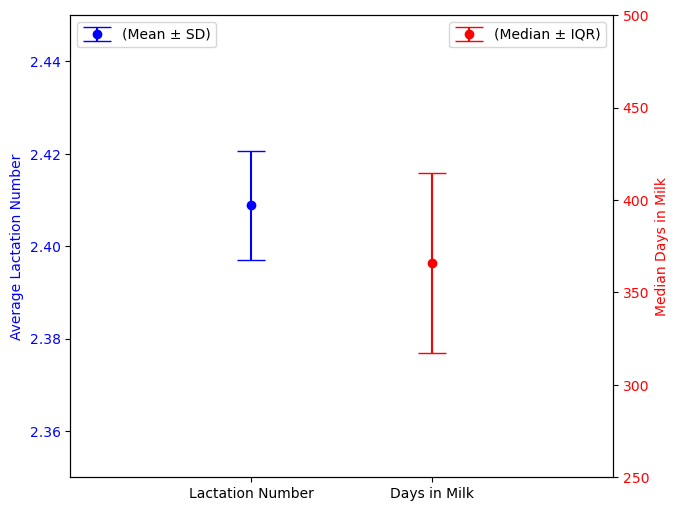

In [63]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(7, 6))

x1 = 0.4
x2 = 0.6

N = len(summary_df)

# Lactation number
lat_mean = summary_df['average_lactation_number'].mean()
lat_sem = summary_df['average_lactation_number'].std()
lat_ci95 = 1 * lat_sem
lat_max = max(lat_mean + lat_ci95, summary_df['average_lactation_number'].max())
ax1.errorbar(
    x=x1, y=lat_mean, yerr=lat_ci95,
    fmt='o', color='blue', capsize=10, label='(Mean ± SD)'
)
ax1.set_ylabel('Average Lactation Number', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Expand y-limits to 150%
ax1.set_ylim(2.35, 2.45)
# Days in milk
dim_median = summary_df['median_days_in_milk'].median()
dim_iqr = summary_df['iqr_days_in_milk'].median()
dim_max = max(dim_median + (dim_iqr / 2), summary_df['median_days_in_milk'].max())
ax2 = ax1.twinx()
ax2.errorbar(
    x=x2, y=dim_median, yerr=dim_iqr/2,
    fmt='o', color='red', capsize=10, label='(Median ± IQR)'
)
ax2.set_ylabel('Median Days in Milk', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Expand y-limits to 150%
ax2.set_ylim(250, 500)

# Center x-ticks
ax1.set_xticks([x1, x2])
ax1.set_xticklabels(['Lactation Number', 'Days in Milk'])
ax1.set_xlim(0.2, 0.8)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# plt.tight_layout()
plt.savefig("dim_lact4.tiff", dpi = 300)
plt.show()


In [123]:
summary_lact4.to_csv("farm4_lact_sum.csv", index = False)